Important: Only a small portion of the dataset is included here for demonstration purposes. The notebook workflow and analysis remain the same as the full project.

## "US Accidents Data Analysis (2016-2023):EDA & Weather Impact"

##  Project Overview
This project performs an end-to-end data analysis on the **US Road Accidents dataset (2016–2023)** to identify trends and patterns related to **accident frequency, severity, time, location, and weather conditions**.  
The project follows a structured **ETL (Extract, Transform, Load)** and **Exploratory Data Analysis (EDA)** workflow to clean raw data, engineer features, and generate meaningful insights for road safety analysis.


## Project Objectives
- Extract and analyze a large-scale **US road accidents dataset (2016–2023)**.
- Clean and preprocess data by handling missing values, fixing data types, removing duplicates, and treating outliers.
- Perform feature engineering to create time-based and contextual features such as **Year, Month, Hour, DayOfWeek, and Accident Duration**.
- Conduct **Exploratory Data Analysis (EDA)** to identify trends in accident severity, time patterns, and location hotspots.
- Analyze the impact of **weather conditions** on accident frequency and severity.
- Generate insights to support **road safety improvements, dashboard reporting, and future predictive modeling**.


##  Business Problem
Road accidents are a major concern for public safety and transportation planning in the United States.  
Understanding **when, where, and under what conditions accidents occur most frequently and severely** is critical for:
- Improving traffic management
- Enhancing road safety infrastructure
- Optimizing emergency response systems  

This project aims to provide data-driven insights to support better decision-making in these areas.


## 3. Dataset Description
- **Dataset Name:** US Accidents (2016–2023)
- **Source:** Public traffic accident records
- **File Size:** ~3GB
- **Records:** Millions of accident entries

### Key Features:
- Accident Severity
- Time information (`Start_Time`, `End_Time`)
- Location details (State, City, County, Latitude, Longitude)
- Weather data (Temperature, Visibility, Wind Speed, Precipitation)
- Road and traffic features (Traffic Signals, Junctions, Crossings)

The dataset required extensive preprocessing due to missing values, inconsistent data types, and outliers.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv(r"C:\Users\praka\Downloads\US_Accidents_March23.csv")


In [ ]:
df

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.010,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.010,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.002480,-117.379360,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.766960,-117.148060,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.775450,-117.847790,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.992460,-118.403020,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day


**DATA UNDERSTANDING**

In [ ]:
df.columns


Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [ ]:
df.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

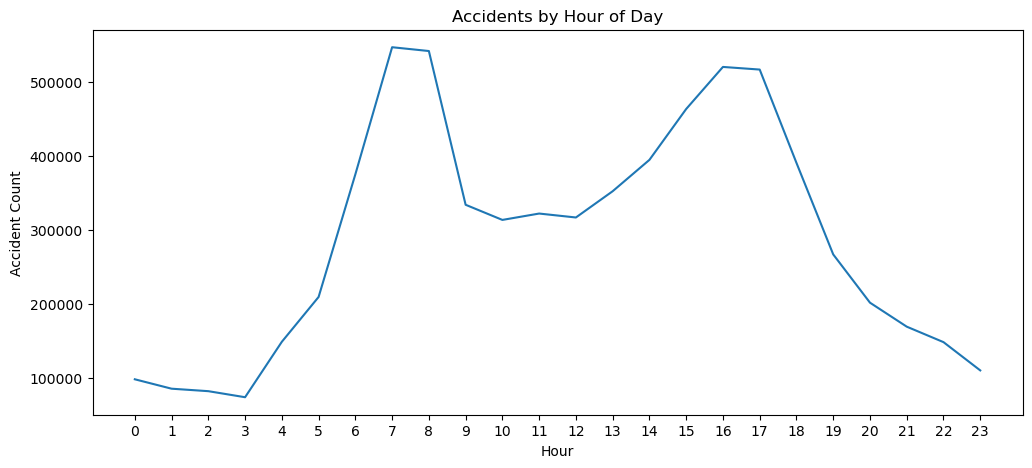

In [ ]:
hourly = df["Hour"].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Accident Count")
plt.xticks(range(0,24))
plt.show()


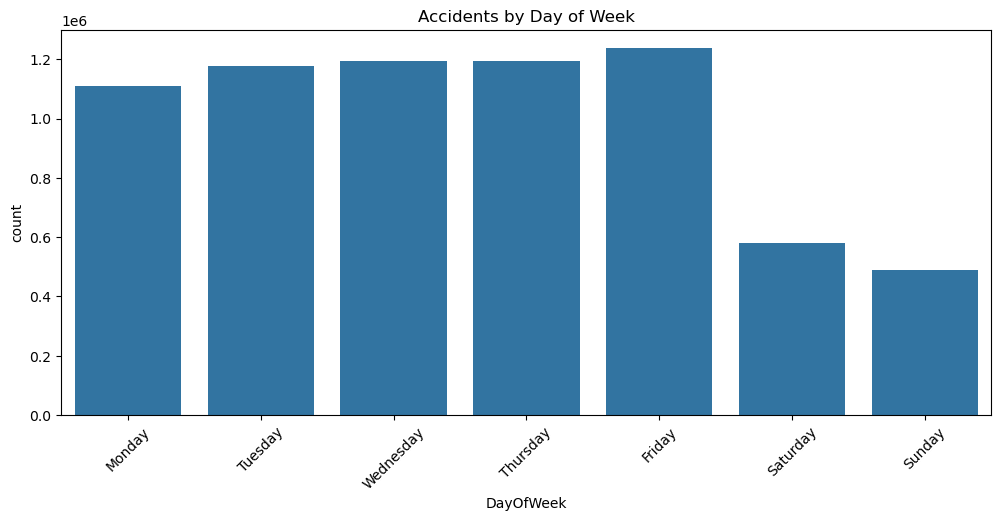

In [ ]:
days_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(12,5))
sns.countplot(data=df, x="DayOfWeek", order=days_order)
plt.title("Accidents by Day of Week")
plt.xticks(rotation=45)
plt.show()


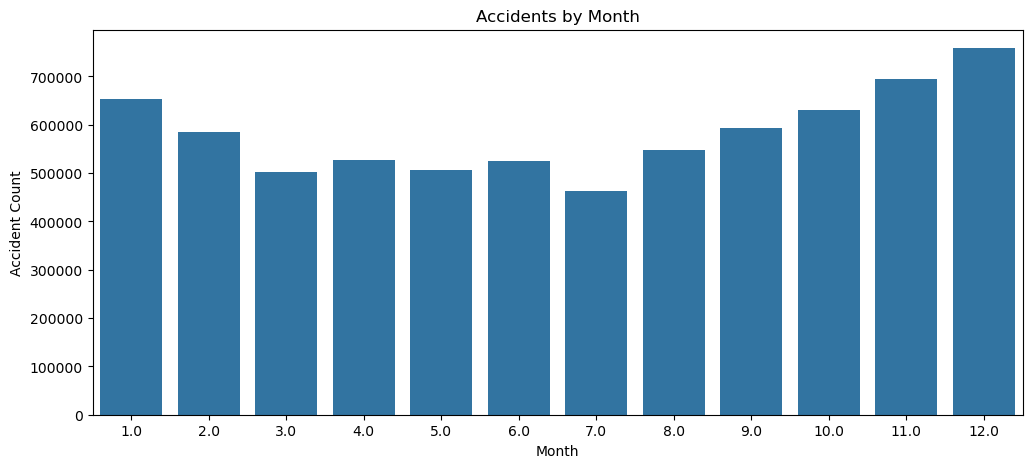

In [ ]:
monthly = df["Month"].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Accident Count")
plt.show()


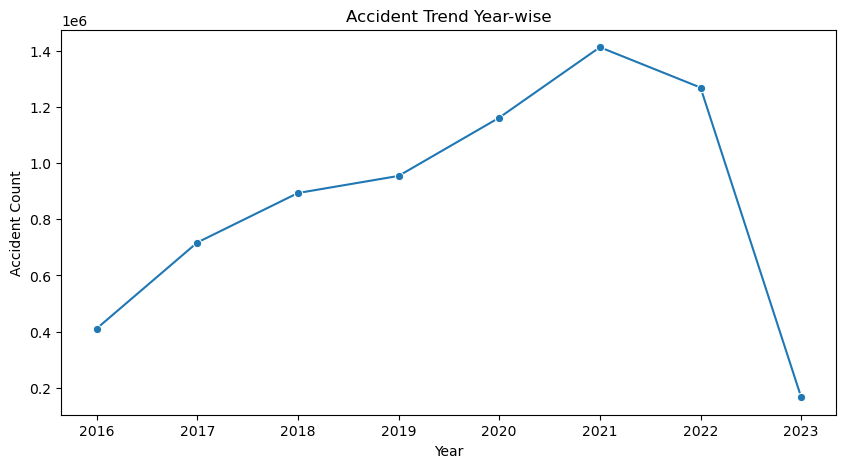

In [ ]:
yearly_trend = df.groupby("Year")["ID"].count()

plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker="o")
plt.title("Accident Trend Year-wise")
plt.xlabel("Year")
plt.ylabel("Accident Count")
plt.xticks(yearly_trend.index)
plt.show()



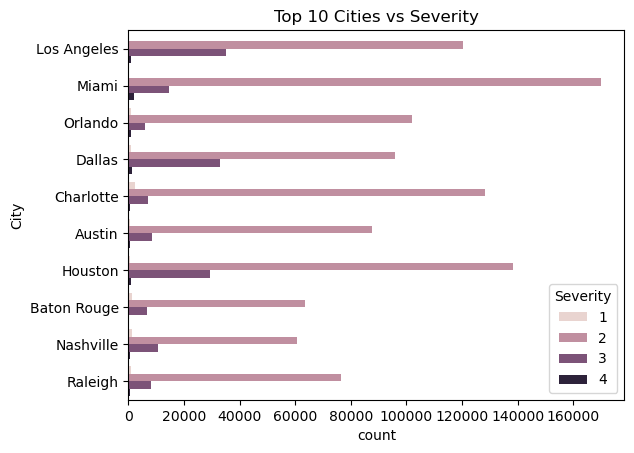

In [ ]:
top10_city_names = df["City"].value_counts().head(10).index
df_city = df[df["City"].isin(top10_city_names)]

sns.countplot(data=df_city, y="City", hue="Severity")
plt.title("Top 10 Cities vs Severity")
plt.show()


##  Key Insights
- Accident frequency is highest during **morning and evening rush hours**, indicating traffic congestion as a major factor.
- A small number of **states and cities contribute to a large proportion of total accidents**, highlighting regional hotspots.
- **Clear and Cloudy weather** conditions show the highest accident counts due to their frequent occurrence.
- **Adverse weather conditions** such as **Rain, Fog, and Snow** are associated with a **higher percentage of severe accidents**.
- Night-time and weekend accidents tend to show **slightly higher severity levels**.
- Outlier analysis revealed rare but high-impact accidents with long distances and durations.


## Recommendations

- **Traffic Control:** Increase monitoring and congestion management during peak hours.
- **Weather-Based Alerts:** Implement dynamic warnings and speed regulations during poor weather conditions.
- **Infrastructure Improvements:** Focus safety upgrades in high-accident states and cities.
- **Emergency Planning:** Optimize emergency response allocation based on time and location trends.
- **Advanced Analytics:** Use the cleaned dataset for predictive modeling and dashboard development.


## Project Conclusions

This project successfully delivered an end-to-end **ETL and Exploratory Data Analysis (EDA)** on the **US Accidents dataset (2016–2023)**, transforming raw accident records into meaningful insights.

- The dataset was extracted from a large CSV file and carefully examined for **data structure, data types, missing values, and duplicate records**.
- Missing values were handled using:
  - **Median imputation** for numerical features such as Temperature, Humidity, Wind Speed, and Visibility.
  - **"Unknown" replacement** for categorical features including Weather Condition, Airport Code, and Twilight information.
- Time-based features such as **Year, Month, Hour, and Day of Week** were engineered from the `Start_Time` column to support trend analysis.
- **Outliers were detected using the IQR (Interquartile Range) method** and visualized through **Box and Whisker plots**, revealing abnormal patterns in accident distance, duration, and weather-related variables.

### Key Findings
- Accident frequency shows clear peaks during **morning and evening rush hours**, highlighting traffic congestion as a major contributing factor.
- A relatively small number of **states, cities, and counties** account for a significant portion of total accidents, indicating geographic hotspots.
- Weather analysis revealed that:
  - **Clear and Cloudy conditions** have the highest accident counts due to their frequent occurrence.
  - **Adverse weather conditions** such as **Rain, Fog, and Snow** are associated with a **higher proportion of severe accidents**, mainly due to reduced visibility and unsafe road conditions.

Overall, the cleaned and processed dataset is now well-structured and ready for **dashboard development, geospatial hotspot analysis, and machine learning applications**. This project demonstrates a strong application of data analytics techniques to derive actionable insights for road safety and traffic management.
